# Notebook 03 — Baseline YOLOv8s Training

## 🎯 Goal:
Train a **YOLOv8s** object detection model as a baseline on the **Corn_augmented** dataset prepared in Notebook 02.

This notebook will:
- Train YOLOv8s with default settings
- Evaluate baseline detection performance
- Visualize training and validation metrics
- Save the trained model for future comparison

### Import Libraries and Set Config

In [1]:
from ultralytics import YOLO
import ultralytics
from pathlib import Path

# Disable MLflow callback to prevent tracking errors
ultralytics.settings.update({'mlflow': False})

# Path to the dataset YAML file from Notebook 02
DATA_CONFIG = Path("Weed-crop RGB dataset/Corn_augmented/corn_augmented.yaml")
MODEL_NAME = "yolov8s.pt"
OUTPUT_DIR = Path("runs/corn_baseline_yolov8s")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

### Load Model and Train

In [2]:
# Load model and start training
model = YOLO(MODEL_NAME)
train_results = model.train(
    data=str(DATA_CONFIG),
    epochs=100,
    imgsz=640,
    batch=4,
    # workers=0,
    name="corn_yolov8s_baseline",
    project=OUTPUT_DIR,
    device=0,   # use GPU 0 if available
    patience=20 # early stopping
)

New https://pypi.org/project/ultralytics/8.3.225 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.217  Python-3.12.4 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Weed-crop RGB dataset\Corn_augmented\corn_augmented.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_sca

### Evaluate Model Performance

In [3]:
# Evaluate baseline model on validation set
metrics = model.val()
metrics

Ultralytics 8.3.217  Python-3.12.4 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
Model summary (fused): 72 layers, 11,130,615 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1593.4277.3 MB/s, size: 3601.5 KB)
val: Scanning C:\Users\Mir Ali\Desktop\AIT\Data Science and AI\3rd Semester\Computer Vision\CV 2025\CV Project\Git Organization\Crop-weed-detection\Weed-crop RGB dataset\Corn_augmented\labels\val.cache... 28 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 28/28  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 0.2it/s 9.9s29.8s
                   all         28        247      0.592      0.571      0.609      0.283
                  Corn         28        172      0.747      0.791      0.806      0.357
             Horseweed          6          9      0.632      0.387      0.622      0.237
                Kochia         13         22      0.365 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 2,  5,  6,  8,  9, 12])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000002A2771EDFD0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047

### Visualize Training and Validation Curves

Visualizing from folder: runs\corn_baseline_yolov8s\corn_yolov8s_baseline3
✅ Found training curve plot:


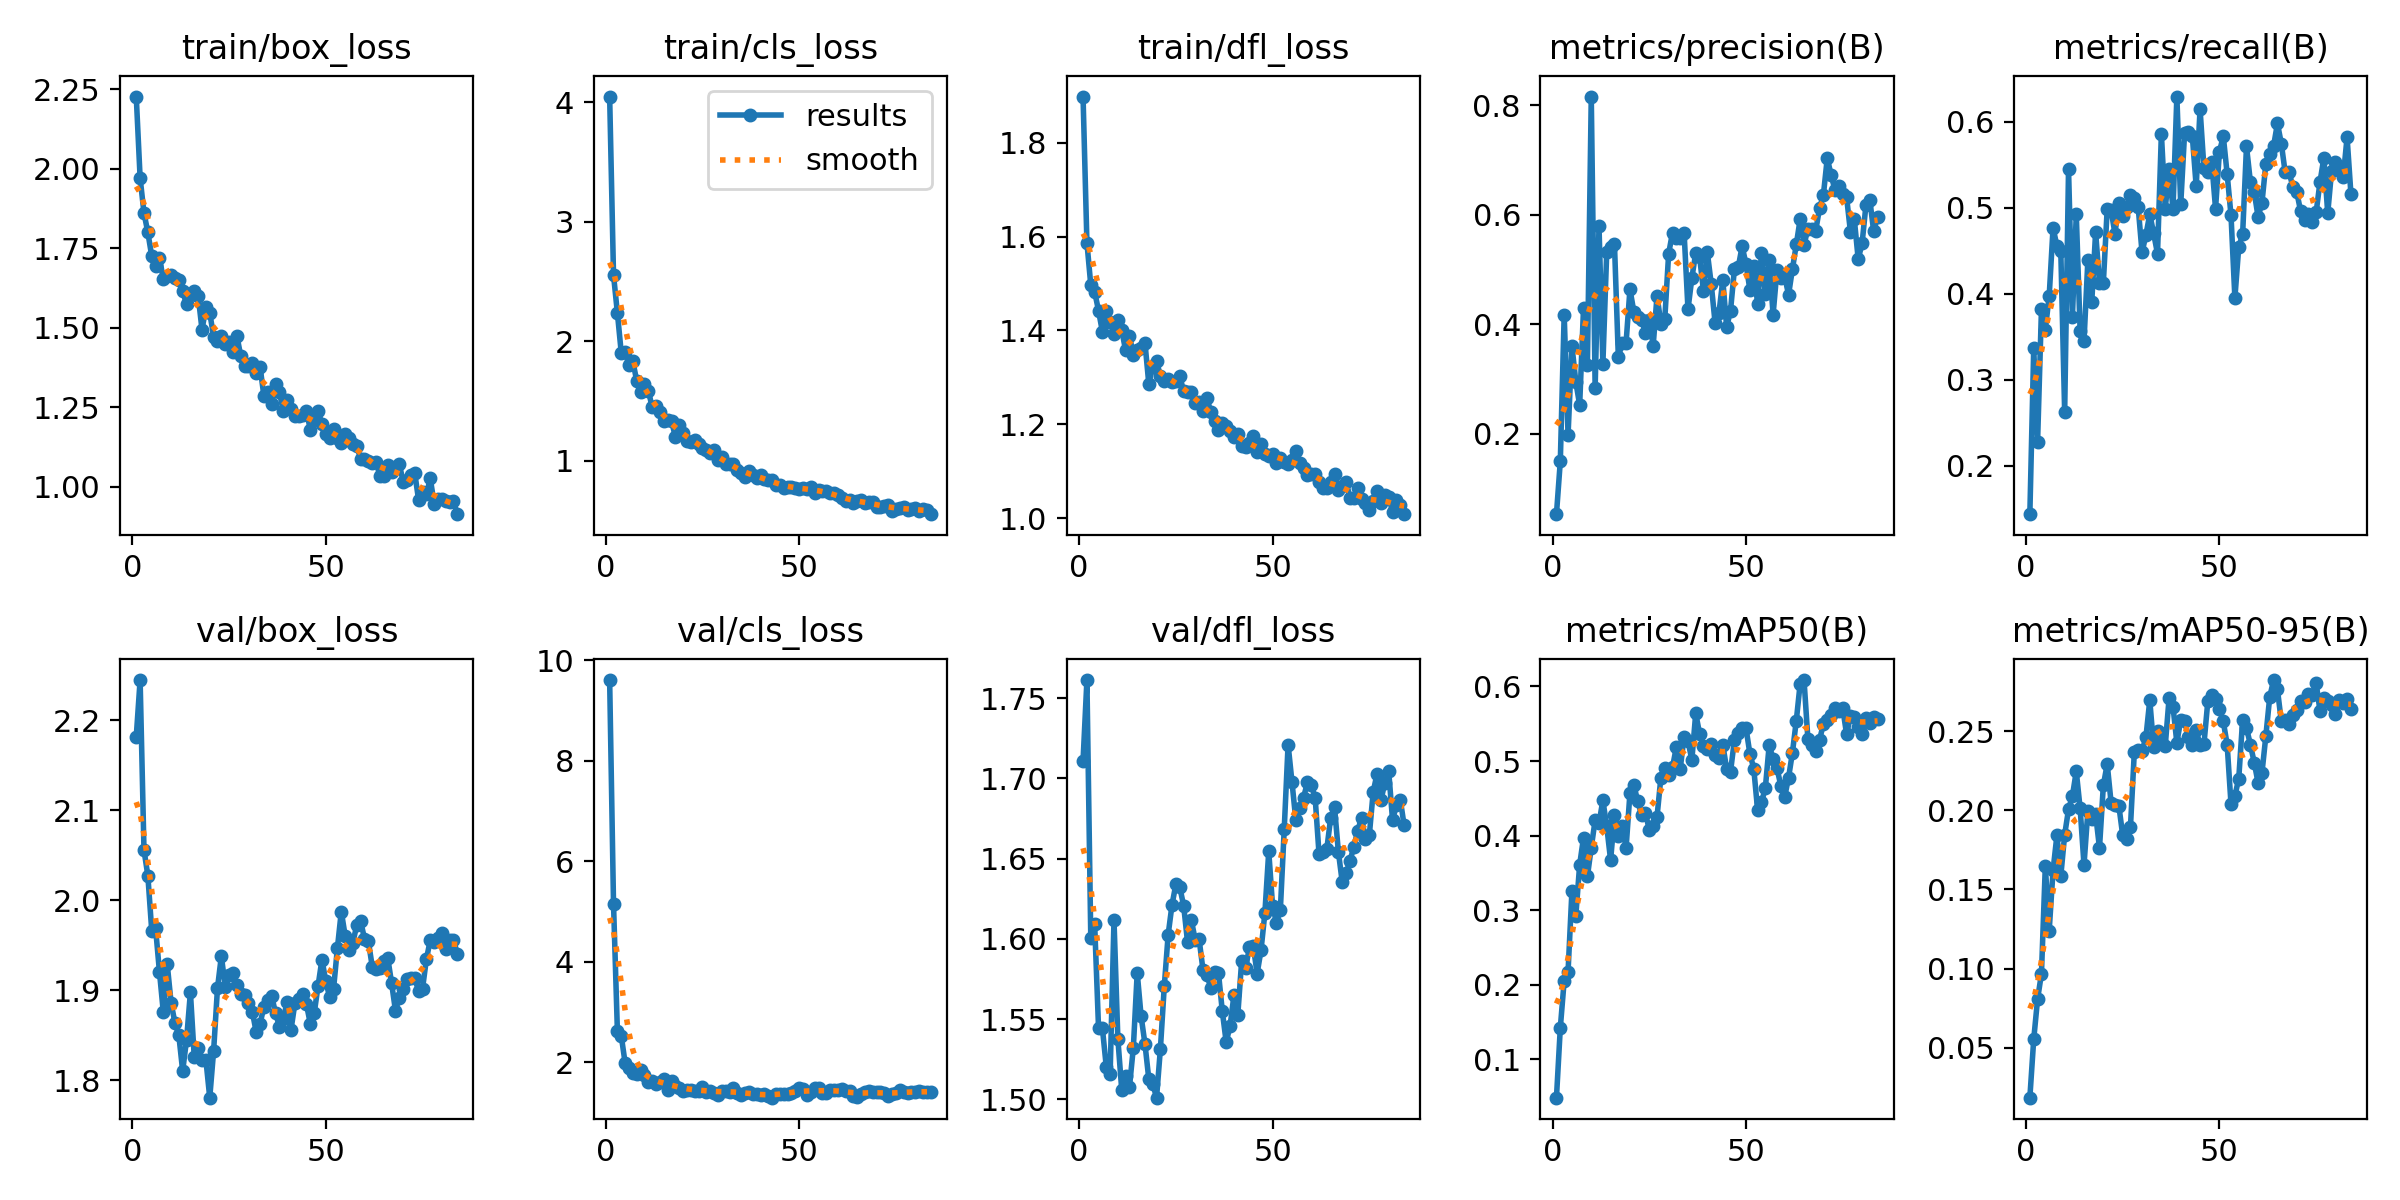

In [4]:
from IPython.display import Image, display
import os
# Dynamically locate the latest run folder
last_run = sorted(OUTPUT_DIR.glob("*"))[-1]
print(f"Visualizing from folder: {last_run}")

# Display training curves (results.png)
results_plot = last_run / 'results.png'
if results_plot.exists():
    print("✅ Found training curve plot:")
    display(Image(filename=results_plot))
else:
    print("⚠️ 'results.png' not found.")

### Save Model Export

In [6]:
# Export trained model weights for future notebooks
export_path = OUTPUT_DIR / "corn_yolov8s_baseline.pt"
model.save(export_path)
print(f"Model saved to: {export_path}")

Model saved to: runs\corn_baseline_yolov8s\corn_yolov8s_baseline.pt


---

## ✅ Baseline YOLOv8s Training — Summary

This notebook established a **baseline object detection model** using the **YOLOv8s** architecture trained on the **Corn_augmented** dataset prepared in Notebook 02.

### 📊 Performance Summary (Validation)

| Metric               | Value  |
|----------------------|---------|
| **mAP@0.5**          | 0.609   |
| **mAP@0.5:0.95**     | 0.283   |
| **Precision (P)**    | 0.592   |
| **Recall (R)**       | 0.571   |

#### 🔍 Class-Wise Details (mAP@0.5 / mAP@0.5:0.95)

| Class             | mAP@0.5 | mAP@[0.5:0.95] |
|-------------------|---------|----------------|
| Corn              | 0.806   | 0.357          |
| Horseweed         | 0.622   | 0.237          |
| Kochia            | 0.284   | 0.077          |
| Ragweed           | 0.706   | 0.377          |
| Redroot Pigweed   | 0.757   | 0.440          |
| Waterhemp         | 0.478   | 0.211          |


### 🔎 Key Observations

- **Strong performance on Corn**, reflecting good representation and object distinctiveness.
- **Weaker performance for small-weed classes** like Kochia and Waterhemp: both precision and recall are significantly lower.
- **Significant gap between mAP@0.5 (0.609) and mAP@0.5:0.95 (0.283)** indicates limitations in bounding box quality and IoU-based localization.
- Inference speed (~39 ms per 640×640 image) shows **real-time feasibility** with further optimizations.

### 🎯 Next Steps

In **Notebook 04**, we'll:
- Enhance the model architecture using **YOLOv11** with a lightweight **SimAM Attention Module** to better emphasize key spatial features, especially for small weeds.
- Keep the training protocol the same to enable fair comparison with this baseline.
- Evaluate improvements in both localization and per-class performance.

This baseline serves as a reference for all future experiments in this project.

---
